# 📊 Marketing Funnel & Conversion Performance Analysis using Python

### 🚀 Project Workflow

This project focuses on analyzing customer behavior in a multi-category e-commerce platform to identify:

- Customer interaction patterns
- Funnel conversion stages
- Product engagement trends
- Purchase behavior
- Conversion drop-offs
- Business opportunities for improving sales

---

### The workflow includes:

1. Data Loading
2. Data Cleaning using Pandas
3. Exploratory Data Analysis (EDA)
4. Univariate Analysis
5. Bivariate Analysis
6. Funnel Analysis
7. Advanced Visualizations using Seaborn & Plotly
8. Customer Behavior Analysis
9. Business Insights & Recommendations

---

### 💡 Example Insights

- Product views are significantly higher than purchases.
- A large percentage of users drop off before reaching checkout.
- Mid-range priced products receive higher engagement.
- Certain product categories dominate user interest.
- Customer activity peaks during specific hours.
- Some brands achieve better purchase conversion rates.
- Cart abandonment is one of the major funnel drop-offs.

---

### 📌 Final Recommendations

- Improve product page experience
- Simplify checkout process
- Run retargeting campaigns for abandoned carts
- Promote high-performing categories more aggressively
- Optimize marketing campaigns during peak traffic hours
- Offer personalized recommendations to users
- Improve conversion strategy between cart and purchase stages

### Importing Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


### Load the Dataset

In [46]:
df = pd.read_csv("2019-Nov.csv", nrows=1000000)

df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-11-01 00:00:00 UTC,view,1003461,2053013555631882655,electronics.smartphone,xiaomi,489.07,520088904,4d3b30da-a5e4-49df-b1a8-ba5943f1dd33
1,2019-11-01 00:00:00 UTC,view,5000088,2053013566100866035,appliances.sewing_machine,janome,293.65,530496790,8e5f4f83-366c-4f70-860e-ca7417414283
2,2019-11-01 00:00:01 UTC,view,17302664,2053013553853497655,NaN,creed,28.31,561587266,755422e7-9040-477b-9bd2-6a6e8fd97387
3,2019-11-01 00:00:01 UTC,view,3601530,2053013563810775923,appliances.kitchen.washer,lg,712.87,518085591,3bfb58cd-7892-48cc-8020-2f17e6de6e7f
4,2019-11-01 00:00:01 UTC,view,1004775,2053013555631882655,electronics.smartphone,xiaomi,183.27,558856683,313628f1-68b8-460d-84f6-cec7a8796ef2


### Dataset Overview

In [56]:
df.shape

(999508, 12)

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 999508 entries, 0 to 999999
Data columns (total 12 columns):
 #   Column         Non-Null Count   Dtype              
---  ------         --------------   -----              
 0   event_time     999508 non-null  datetime64[ns, UTC]
 1   event_type     999508 non-null  object             
 2   product_id     999508 non-null  int64              
 3   category_id    999508 non-null  int64              
 4   category_code  999508 non-null  object             
 5   brand          999508 non-null  object             
 6   price          999508 non-null  float64            
 7   user_id        999508 non-null  int64              
 8   user_session   999508 non-null  object             
 9   date           999508 non-null  object             
 10  hour           999508 non-null  int32              
 11  day            999508 non-null  object             
dtypes: datetime64[ns, UTC](1), float64(1), int32(1), int64(3), object(6)
memory usage: 95.3+ MB

In [49]:
df.describe()

,product_id,category_id,price,user_id
count,1.000000e+06,1.000000e+06,1000000.000000,1.000000e+06
mean,1.060944e+07,2.057550e+18,292.181443,5.352224e+08
std,1.200388e+07,1.892062e+16,347.585961,2.014677e+07
min,1.000978e+06,2.053014e+18,0.000000,2.749691e+08
25%,1.005186e+06,2.053014e+18,69.720000,5.159483e+08
50%,4.900340e+06,2.053014e+18,172.180000,5.307922e+08
75%,1.570018e+07,2.053014e+18,361.970000,5.544839e+08
max,6.170001e+07,2.180737e+18,2574.070000,5.665059e+08


### Data Cleaning

In [58]:
df.isnull().sum()

event_time       0
event_type       0
product_id       0
category_id      0
category_code    0
brand            0
price            0
user_id          0
user_session     0
date             0
hour             0
day              0
dtype: int64

In [59]:
df['brand'] = df['brand'].fillna('Unknown')
df['category_code'] = df['category_code'].fillna('Unknown')

In [60]:
df.duplicated().sum()

np.int64(0)

In [61]:
df.drop_duplicates(inplace=True)

In [62]:
df['event_time'] = pd.to_datetime(df['event_time'])

In [55]:
df['date'] = df['event_time'].dt.date
df['hour'] = df['event_time'].dt.hour
df['day'] = df['event_time'].dt.day_name()

## Exploratory Data Analysis (EDA)

### Univariate Analysis

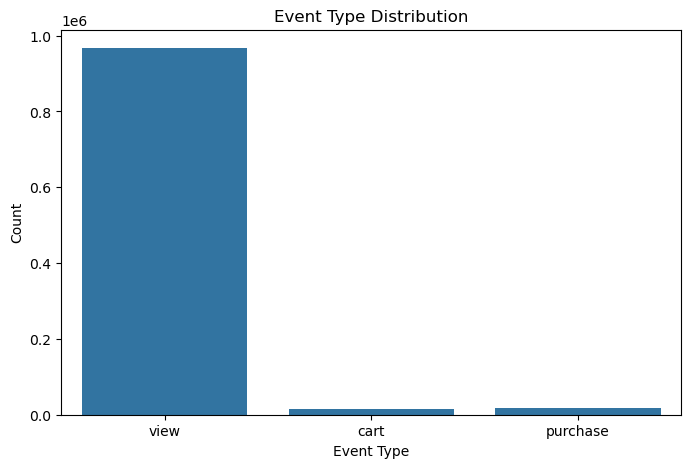

In [63]:
# Event Type
plt.figure(figsize=(8,5))

sns.countplot(x='event_type', data=df)

plt.title("Event Type Distribution")
plt.xlabel("Event Type")
plt.ylabel("Count")

plt.show()

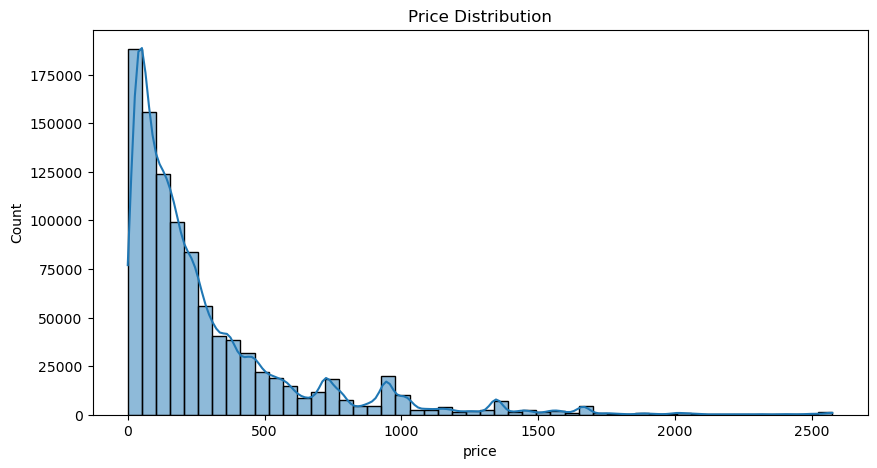

In [64]:
# Price Distribution
plt.figure(figsize=(10,5))

sns.histplot(df['price'], bins=50, kde=True)

plt.title("Price Distribution")

plt.show()

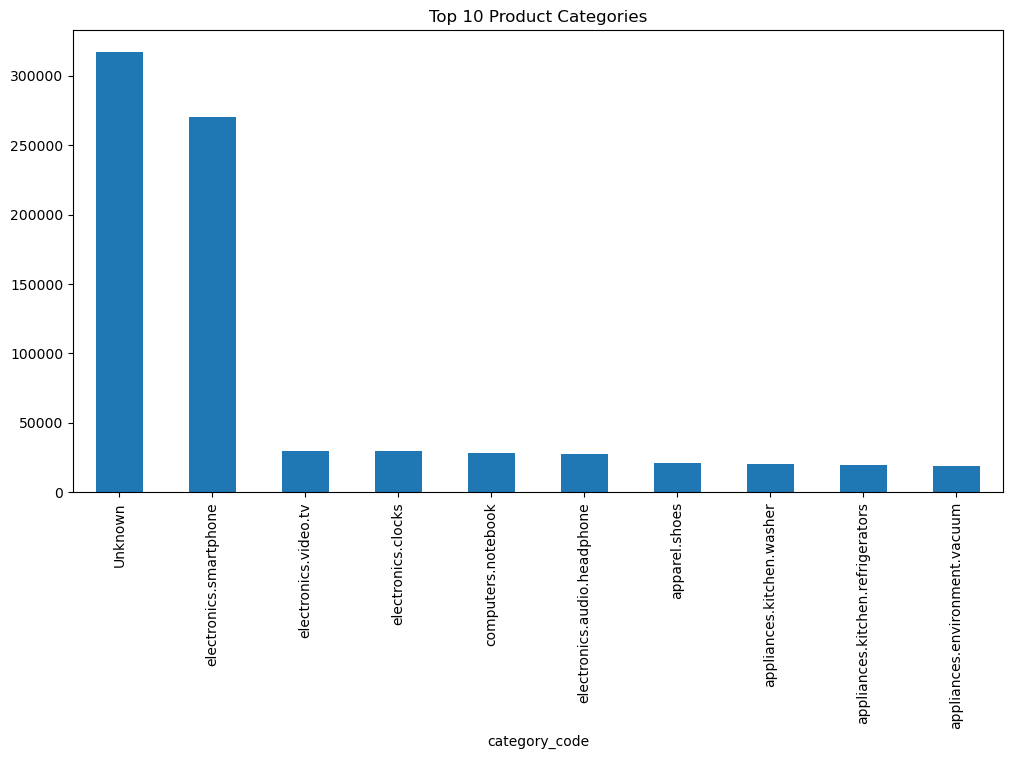

In [65]:
# Top Product Categories
top_categories = df['category_code'].value_counts().head(10)

plt.figure(figsize=(12,6))

top_categories.plot(kind='bar')

plt.title("Top 10 Product Categories")

plt.show()

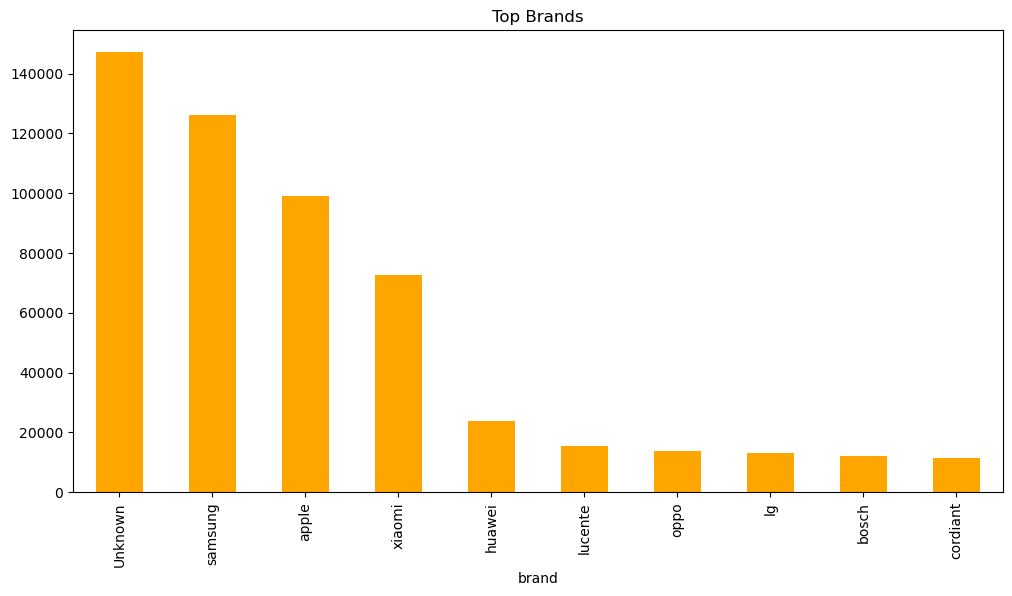

In [66]:
# Top Brands
top_brands = df['brand'].value_counts().head(10)

plt.figure(figsize=(12,6))

top_brands.plot(kind='bar', color='orange')

plt.title("Top Brands")

plt.show()

### Bivariate Analysis

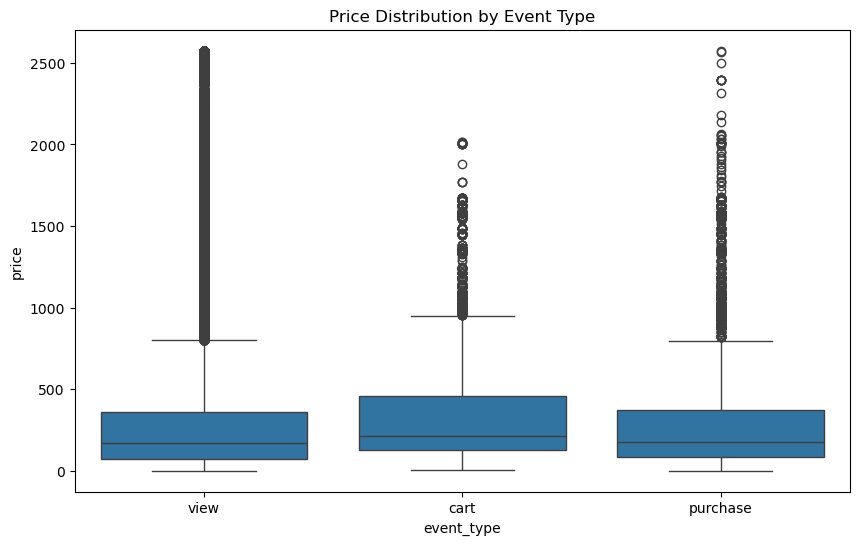

In [67]:
# Price Distribution by Event Type
plt.figure(figsize=(10,6))

sns.boxplot(x='event_type', y='price', data=df)

plt.title("Price Distribution by Event Type")

plt.show()

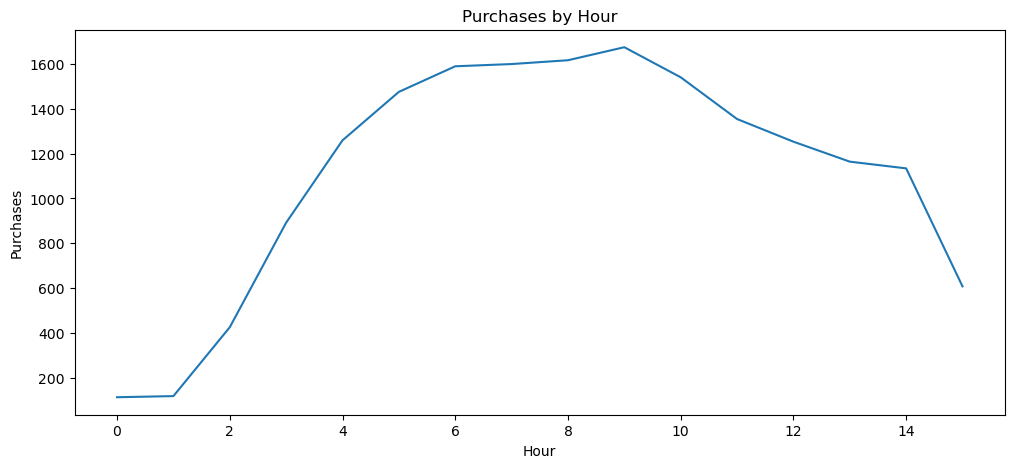

In [68]:
# Purchases by Hour
hourly = purchase_df.groupby('hour').size()

plt.figure(figsize=(12,5))

hourly.plot()

plt.title("Purchases by Hour")

plt.xlabel("Hour")
plt.ylabel("Purchases")

plt.show()

## Funnel Analysis
This is the most important part of the project.

#### Funnel Stages
```
View → Cart → Purchase
```

In [70]:
# Funnel Count
views = len(df[df['event_type'] == 'view'])
cart = len(df[df['event_type'] == 'cart'])
purchase = len(df[df['event_type'] == 'purchase'])

funnel = pd.DataFrame({
    'Stage': ['View', 'Cart', 'Purchase'],
    'Count': [views, cart, purchase]
})

funnel

,Stage,Count
0,View,967187
1,Cart,14505
2,Purchase,17816


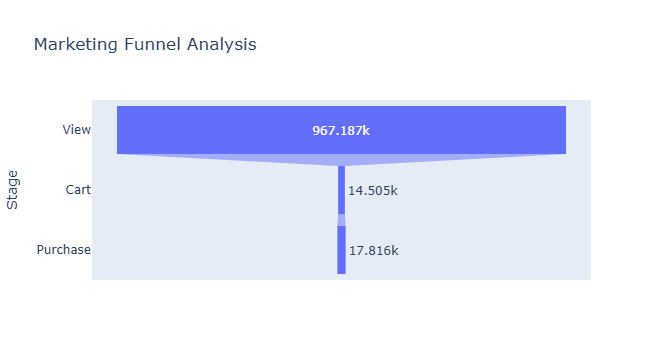

In [71]:
# Funnel Visualisation
fig = px.funnel(
    funnel,
    x='Count',
    y='Stage',
    title='Marketing Funnel Analysis'
)

fig.show()

In [72]:
# Conversion Rates
cart_conversion = (cart/views)*100
purchase_conversion = (purchase/cart)*100

print(cart_conversion)
print(purchase_conversion)

1.4997099836949837
122.82661151327127


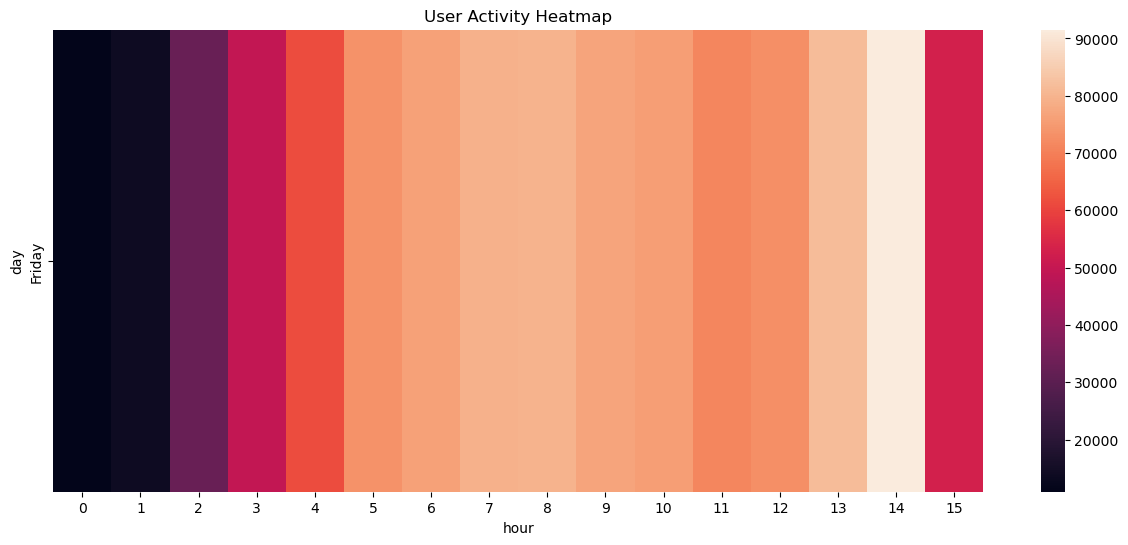

In [45]:
pivot = df.pivot_table(
    index='day',
    columns='hour',
    values='user_id',
    aggfunc='count'
)

plt.figure(figsize=(15,6))

sns.heatmap(pivot)

plt.title("User Activity Heatmap")

plt.show()

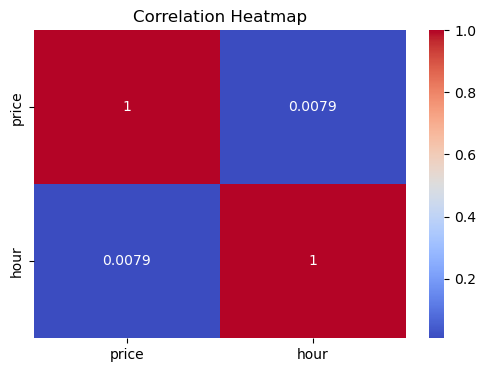

In [74]:
numeric_cols = ['price', 'hour']

corr = df[numeric_cols].corr()

plt.figure(figsize=(6,4))

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

## 📌 Key Business Insights
1. Customer Behavior
    - Most users browse products without purchasing.
    - Product views are significantly higher than purchases.
2. Funnel Performance
    - Major drop-off occurs between View and Cart stages.
    - Cart abandonment affects overall conversion rates.
3. Product Trends
    - Mid-priced products show better conversion.
    - Certain brands dominate purchases.
4. Time-Based Insights
    - Purchases peak during specific hours.
    - Marketing campaigns should target high-activity periods.